In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer

# Handling Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('malnutrition_children_ethiopia.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (4098, 16)

First 5 Rows:
   ID  Age (months)  Gender  Region Mother_Education Household_Wealth_Index  \
0   1            31    Male  Amhara           Higher                 Middle   
1   2            38  Female  Tigray           Higher                 Middle   
2   3             7  Female   SNNPR        Secondary                 Middle   
3   4             7  Female  Amhara           Higher                    Low   
4   5             0    Male  Tigray     No education                   High   

   Height_cm  Weight_kg  Stunting  Underweight  Overweight  Anemia  Malaria  \
0       84.1       19.2         1            1           0       1        1   
1       91.0        6.3         0            0           0       0        1   
2       61.4        5.8         1            1           1       1        1   
3      103.1       12.9         1            0           1       1        0   
4       78.9        7.4         0            0           0       0        1   

   Diarrh

In [3]:
# Initial Data Exploration

# Check target variable distribution
print("\nNutrition Status Distribution:")
print(df['Nutrition_Status'].value_counts())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check data types
print("\nData Types:")
print(df.dtypes)


Nutrition Status Distribution:
Nutrition_Status
Normal          2030
At_Risk         1238
Malnourished     830
Name: count, dtype: int64

Missing Values:
ID                        0
Age (months)              0
Gender                    0
Region                    0
Mother_Education          0
Household_Wealth_Index    0
Height_cm                 0
Weight_kg                 0
Stunting                  0
Underweight               0
Overweight                0
Anemia                    0
Malaria                   0
Diarrhea                  0
TB                        0
Nutrition_Status          0
dtype: int64

Data Types:
ID                          int64
Age (months)                int64
Gender                     object
Region                     object
Mother_Education           object
Household_Wealth_Index     object
Height_cm                 float64
Weight_kg                 float64
Stunting                    int64
Underweight                 int64
Overweight                  int

In [4]:
# Data Quality Check
# risk indicator columns
risk_columns = ['Stunting', 'Underweight', 'Overweight', 'Anemia', 'Malaria', 'Diarrhea', 'TB']

# total risk factors per row
df['Risk_Count'] = df[risk_columns].sum(axis=1)

# "Normal" cases with multiple risk factors (potential mislabels)
normal_with_risks = df[(df['Nutrition_Status'] == 'Normal') & (df['Risk_Count'] >= 2)]
print(f"\n1. Normal cases with 2+ risk factors: {len(normal_with_risks)}")

# "At_Risk/Malnourished" cases with no risk factors
at_risk_labels = ['At_Risk', 'Malnourished', 'Severe']
risky_no_factors = df[(df['Nutrition_Status'].isin(at_risk_labels)) & (df['Risk_Count'] == 0)]
print(f"2. At_Risk/Malnourished cases with 0 risk factors: {len(risky_no_factors)}")

# Biologically impossible cases (Underweight AND Overweight)
impossible_weight = df[(df['Underweight'] == 1) & (df['Overweight'] == 1)]
print(f"3. Both Underweight AND Overweight (impossible): {len(impossible_weight)}")

# Check for anthropometric outliers
def check_anthropometric_outliers(df):
    """Check for biologically impossible height/weight values"""
    outliers = df[
        (df['Age (months)'] <= 6) & (df['Height_cm'] > 80) |
        (df['Age (months)'] <= 12) & (df['Height_cm'] > 100) |
        (df['Age (months)'] <= 24) & (df['Height_cm'] > 120) |
        (df['Weight_kg'] < 2) | (df['Weight_kg'] > 30)
    ]
    return outliers

anthropometric_outliers = check_anthropometric_outliers(df)
print(f"4. Anthropometric outliers: {len(anthropometric_outliers)}")


1. Normal cases with 2+ risk factors: 1911
2. At_Risk/Malnourished cases with 0 risk factors: 8
3. Both Underweight AND Overweight (impossible): 995
4. Anthropometric outliers: 379


In [5]:
# Data Cleaning
# 5.1 Create a copy for cleaning
df_clean = df.copy()

# Fix biologically impossible cases (Underweight AND Overweight)
# Set Overweight to 0 if both are 1 (Underweight takes priority in malnutrition context)
df_clean.loc[(df_clean['Underweight'] == 1) & (df_clean['Overweight'] == 1), 'Overweight'] = 0
print(f"Fixed {len(impossible_weight)} impossible Underweight/Overweight cases")

# Handle anthropometric outliers using IQR method
def remove_outliers_iqr(df, column, multiplier=1.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

initial_rows = len(df_clean)
df_clean = remove_outliers_iqr(df_clean, 'Height_cm', multiplier=2)
df_clean = remove_outliers_iqr(df_clean, 'Weight_kg', multiplier=2)
print(f"Removed {initial_rows - len(df_clean)} outlier rows")

# Handle missing values
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

numerical_cols = ['Age (months)', 'Height_cm', 'Weight_kg']
categorical_cols = ['Gender', 'Region', 'Mother_Education', 'Household_Wealth_Index']

df_clean[numerical_cols] = imputer_num.fit_transform(df_clean[numerical_cols])
df_clean[categorical_cols] = imputer_cat.fit_transform(df_clean[categorical_cols])

print(f"Missing values handled. Remaining missing: {df_clean.isnull().sum().sum()}")

Fixed 995 impossible Underweight/Overweight cases
Removed 0 outlier rows
Missing values handled. Remaining missing: 0


In [6]:
# Create Binary Target Varianbles
# Recalculate Risk_Count after cleaning
df_clean['Risk_Count'] = df_clean[risk_columns].sum(axis=1)

# Based on original labels
def create_binary_target_from_labels(status):
    if status in ['Normal']:
        return 0  # Low Risk
    else:  # At_Risk, Malnourished, Severe, etc.
        return 1  # Risk

# Based on risk indicators
def create_binary_target_from_indicators(row):
    # Critical conditions that indicate risk
    critical_conditions = row['Stunting'] + row['Underweight'] + row['Anemia']
    disease_conditions = row['Malaria'] + row['Diarrhea'] + row['TB']
    
    if critical_conditions >= 1 or disease_conditions >= 2:
        return 1  # Risk
    else:
        return 0  # Low Risk

# Use indicator-based target 
df_clean['Target'] = df_clean.apply(create_binary_target_from_indicators, axis=1)

print("\nBinary Target Distribution:")
print(df_clean['Target'].value_counts())
print(f"\nClass Balance: {df_clean['Target'].value_counts(normalize=True)}")


Binary Target Distribution:
Target
1    3870
0     228
Name: count, dtype: int64

Class Balance: Target
1    0.944363
0    0.055637
Name: proportion, dtype: float64


In [7]:
# Feature Engieeering
# Create BMI Index
df_clean['BMI'] = np.where(
    df_clean['Height_cm'] > 0,
    df_clean['Weight_kg'] / ((df_clean['Height_cm'] / 100) ** 2),
    np.nan
)

# Create composite scores
df_clean['Disease_Count'] = df_clean[['Malaria', 'Diarrhea', 'TB']].sum(axis=1)
df_clean['Malnutrition_Score'] = df_clean[['Stunting', 'Underweight', 'Anemia']].sum(axis=1)

# Age groups
df_clean['Age_Group'] = pd.cut(
    df_clean['Age (months)'],
    bins=[0, 6, 12, 24, 36, 60, np.inf],
    labels=['0-6m', '6-12m', '12-24m', '24-36m', '36-60m', '60+m'],
    include_lowest=True
)

# Weight-for-Age ratio
df_clean['Weight_Age_Ratio'] = np.where(
    df_clean['Age (months)'] > 0,
    df_clean['Weight_kg'] / df_clean['Age (months)'],
    np.nan
)

# Height-for-Age ratio
df_clean['Height_Age_Ratio'] = np.where(
    df_clean['Age (months)'] > 0,
    df_clean['Height_cm'] / df_clean['Age (months)'],
    np.nan
)

# Remove biologically impossible records
print(f"Rows before removing impossible records: {len(df_clean)}")

df_clean = df_clean[
    ~((df_clean['Age (months)'] <= 6) & (df_clean['Height_cm'] > 80)) &
    ~((df_clean['Age (months)'] <= 12) & (df_clean['Height_cm'] > 100)) &
    ~((df_clean['Age (months)'] <= 24) & (df_clean['Weight_kg'] > 20))
]

print(f"Rows after removing impossible records: {len(df_clean)}")

#Cap ratio features to reasonable ranges
df_clean['Weight_Age_Ratio'] = df_clean['Weight_Age_Ratio'].clip(0, 5)
df_clean['Height_Age_Ratio'] = df_clean['Height_Age_Ratio'].clip(0, 30)
df_clean['BMI'] = df_clean['BMI'].clip(5, 40)

# Fill any remaining NaN in engineered features
df_clean['BMI'] = df_clean['BMI'].fillna(df_clean['BMI'].median())
df_clean['Weight_Age_Ratio'] = df_clean['Weight_Age_Ratio'].fillna(df_clean['Weight_Age_Ratio'].median())
df_clean['Height_Age_Ratio'] = df_clean['Height_Age_Ratio'].fillna(df_clean['Height_Age_Ratio'].median())



Rows before removing impossible records: 4098
Rows after removing impossible records: 3719


In [8]:
# Encoding
# Gender - Binary encoding
df_clean['Gender_Encoded'] = LabelEncoder().fit_transform(df_clean['Gender'])

# Region - One-hot encoding
region_dummies = pd.get_dummies(df_clean['Region'], prefix='Region')
df_clean = pd.concat([df_clean, region_dummies], axis=1)

# Mother_Education - Ordinal encoding with unknown handling
education_order = ['No education', 'Primary', 'Secondary', 'Higher']
ordinal_encoder = OrdinalEncoder(
    categories=[education_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
df_clean['Mother_Education_Encoded'] = ordinal_encoder.fit_transform(
    df_clean[['Mother_Education']]
)

# Household_Wealth_Index - Ordinal encoding with unknown handling
wealth_order = ['Low', 'Middle', 'High']
ordinal_encoder_wealth = OrdinalEncoder(
    categories=[wealth_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
df_clean['Wealth_Index_Encoded'] = ordinal_encoder_wealth.fit_transform(
    df_clean[['Household_Wealth_Index']]
)

# Age_Group
df_clean['Age_Group'] = df_clean['Age_Group'].fillna(df_clean['Age_Group'].mode()[0])
age_group_order = ['0-6m', '6-12m', '12-24m', '24-36m', '36-60m', '60+m']
ordinal_encoder_age = OrdinalEncoder(
    categories=[age_group_order],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
df_clean['Age_Group_Encoded'] = ordinal_encoder_age.fit_transform(
    df_clean[['Age_Group']].astype(str) 
)

print("Categorical encoding completed!")
print(f"Final dataset shape: {df_clean.shape}")


Categorical encoding completed!
Final dataset shape: (3719, 33)


In [9]:
# Feature Selection
feature_columns = [
    # Demographic
    'Age (months)', 'Gender_Encoded', 'Age_Group_Encoded',
    # Socioeconomic
    'Mother_Education_Encoded', 'Wealth_Index_Encoded',
    # Anthropometric
    'Height_cm', 'Weight_kg', 'BMI', 'Weight_Age_Ratio', 'Height_Age_Ratio',
    # Composite Scores
    'Disease_Count',
]

# Add region dummy columns
region_cols = [col for col in df_clean.columns if col.startswith('Region_')]
feature_columns.extend(region_cols)

print(f"Selected {len(feature_columns)} features:")
print(feature_columns)

# Create feature matrix and target
X = df_clean[feature_columns].copy()
y = df_clean['Target'].copy()

print(f"\nFeature Matrix Shape: {X.shape}")
print(f"Target Shape: {y.shape}")

Selected 16 features:
['Age (months)', 'Gender_Encoded', 'Age_Group_Encoded', 'Mother_Education_Encoded', 'Wealth_Index_Encoded', 'Height_cm', 'Weight_kg', 'BMI', 'Weight_Age_Ratio', 'Height_Age_Ratio', 'Disease_Count', 'Region_Addis Ababa', 'Region_Amhara', 'Region_Oromia', 'Region_SNNPR', 'Region_Tigray']

Feature Matrix Shape: (3719, 16)
Target Shape: (3719,)


In [10]:
# Train Test SPlit
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"\nTraining Target Distribution:\n{y_train.value_counts()}")
print(f"\nTesting Target Distribution:\n{y_test.value_counts()}")

Training set: 2975 samples
Testing set: 744 samples

Training Target Distribution:
Target
1    2812
0     163
Name: count, dtype: int64

Testing Target Distribution:
Target
1    703
0     41
Name: count, dtype: int64


In [11]:
# Feature Scaling and Class Imbalance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_balanced).value_counts().to_dict()}")

Features scaled using StandardScaler
Before SMOTE: {1: 2812, 0: 163}
After SMOTE: {1: 2812, 0: 2812}


In [12]:
# Individual Model Training
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

results = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    model.fit(X_train_balanced, y_train_balanced)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

# Results comparison
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print("\n=== MODEL COMPARISON ===")
print(results_df.to_string(index=False))



Training Logistic Regression...
  Accuracy: 0.6519
  F1-Score: 0.7781
  ROC-AUC: 0.7342

Training Random Forest...
  Accuracy: 0.9234
  F1-Score: 0.9602
  ROC-AUC: 0.7505

Training Gradient Boosting...
  Accuracy: 0.9315
  F1-Score: 0.9645
  ROC-AUC: 0.7452

Training XGBoost...
  Accuracy: 0.9207
  F1-Score: 0.9586
  ROC-AUC: 0.7638

Training SVM...
  Accuracy: 0.7648
  F1-Score: 0.8640
  ROC-AUC: 0.7228

=== MODEL COMPARISON ===
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
            XGBoost  0.920699   0.945983 0.971550  0.958596 0.763834
      Random Forest  0.923387   0.943681 0.977240  0.960168 0.750529
  Gradient Boosting  0.931452   0.945355 0.984353  0.964460 0.745169
Logistic Regression  0.651882   0.978448 0.645804  0.778063 0.734240
                SVM  0.764785   0.952055 0.790896  0.864025 0.722791


In [13]:
# Model Evaluation

best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")

# Predictions
y_pred_best = best_model.predict(X_test_scaled)
y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Low Risk', 'Risk']))

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_best)
print(cm)

Best Model: XGBoost

Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.09      0.05      0.06        41
        Risk       0.95      0.97      0.96       703

    accuracy                           0.92       744
   macro avg       0.52      0.51      0.51       744
weighted avg       0.90      0.92      0.91       744


Confusion Matrix:
[[  2  39]
 [ 20 683]]


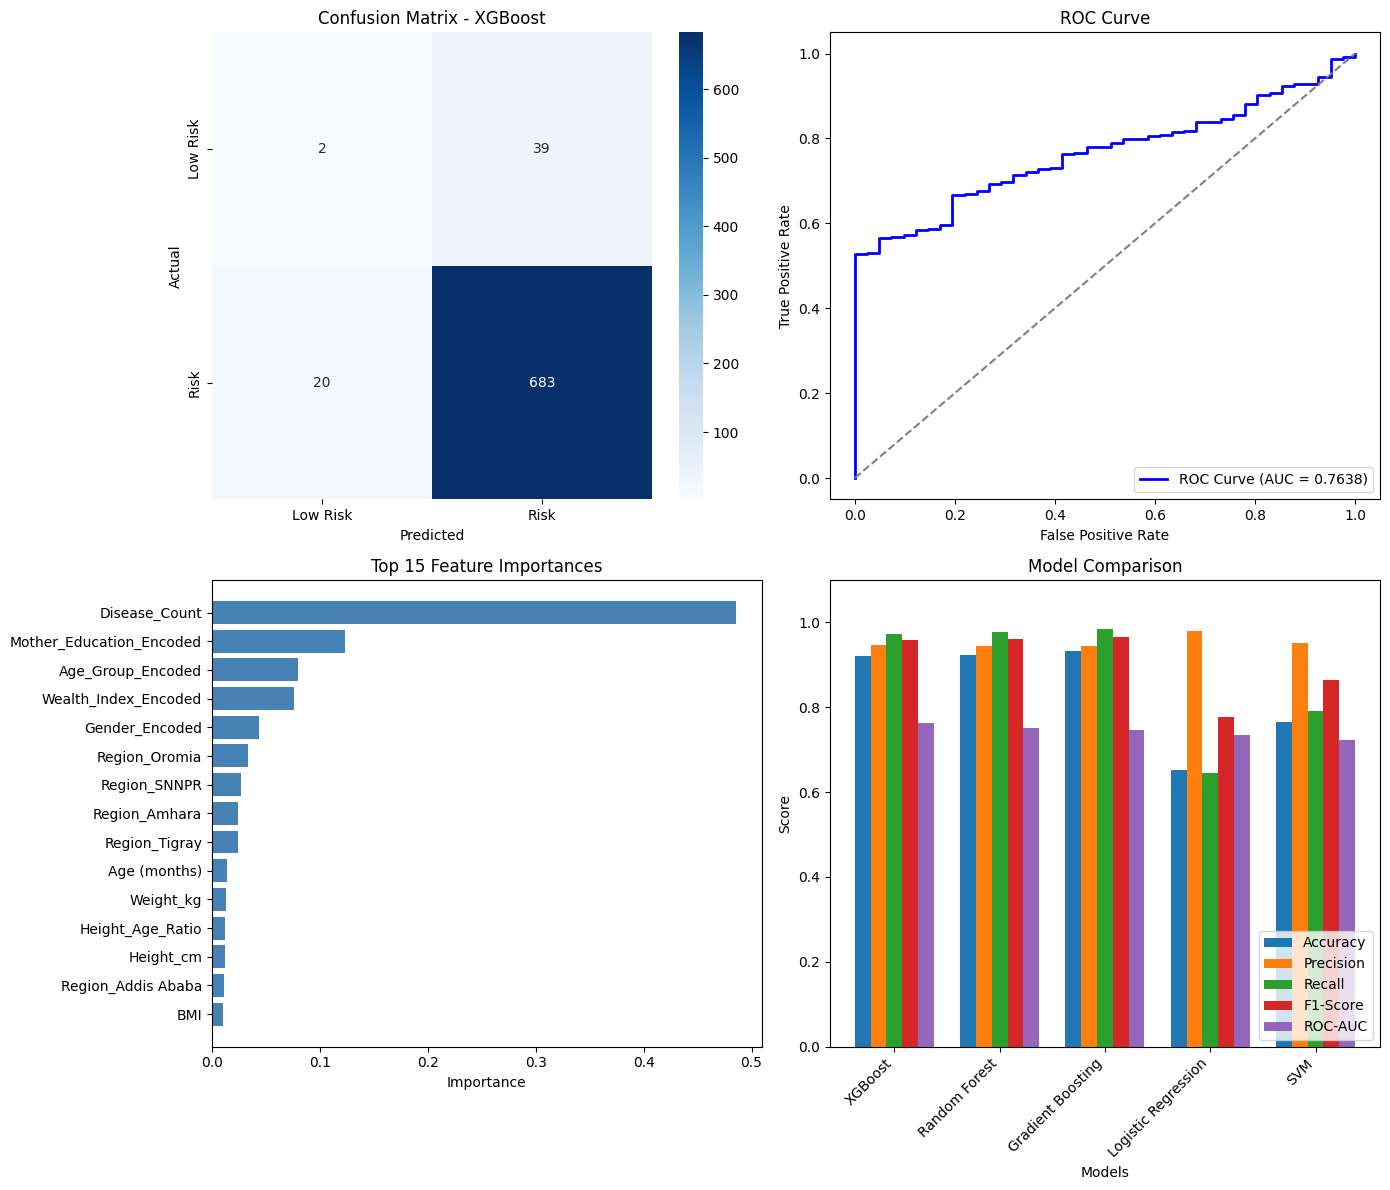

Visualizations saved to 'model_evaluation.png'


In [14]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Confusion Matrix Heatmap
ax1 = axes[0, 0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Low Risk', 'Risk'],
            yticklabels=['Low Risk', 'Risk'])
ax1.set_title(f'Confusion Matrix - {best_model_name}')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# ROC Curve
ax2 = axes[0, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)
ax2.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_proba_best):.4f})')
ax2.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(loc='lower right')

# Feature Importance (for tree-based models)
ax3 = axes[1, 0]
if hasattr(best_model, 'feature_importances_'):
    importances = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True).tail(15)
    
    ax3.barh(importances['Feature'], importances['Importance'], color='steelblue')
    ax3.set_title('Top 15 Feature Importances')
    ax3.set_xlabel('Importance')
else:
    ax3.text(0.5, 0.5, 'Feature importance not available for this model', 
             ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Feature Importances')

# Model Comparison
ax4 = axes[1, 1]
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.15

for i, metric in enumerate(metrics_to_plot):
    ax4.bar(x + i * width, results_df[metric], width, label=metric)

ax4.set_xlabel('Models')
ax4.set_ylabel('Score')
ax4.set_title('Model Comparison')
ax4.set_xticks(x + width * 2)
ax4.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax4.legend(loc='lower right')
ax4.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizations saved to 'model_evaluation.png'")



In [15]:
# Cross Validation

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train_balanced, y_train_balanced, cv=cv, scoring='roc_auc')

print(f"5-Fold Cross-Validation ROC-AUC Scores: {cv_scores}")
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Save Model and Artifacts
import joblib

# Save the best model
joblib.dump(best_model, 'best_model.pkl')
print("Best model saved to 'best_model.pkl'")

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved to 'scaler.pkl'")

# Save feature columns
with open('feature_columns.txt', 'w') as f:
    f.write('\n'.join(feature_columns))
print("Feature columns saved to 'feature_columns.txt'")

# Save results
results_df.to_csv('model_comparison_results.csv', index=False)
print("Model comparison results saved to 'model_comparison_results.csv'")

# Prediction function (can use for test)

def predict_risk(new_data, model_path='best_model.pkl', scaler_path='scaler.pkl'):
    """
    Predict malnutrition risk for new data
    
    Parameters:
    -----------
    new_data : pd.DataFrame
        DataFrame with the same features as training data
    
    Returns:
    --------
    predictions : array
        0 = Low Risk, 1 = Risk
    probabilities : array
        Probability of being at Risk
    """
    # Load model and scaler
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    
    # Scale features
    new_data_scaled = scaler.transform(new_data)
    
    # Predict
    predictions = model.predict(new_data_scaled)
    probabilities = model.predict_proba(new_data_scaled)[:, 1]
    
    return predictions, probabilities


5-Fold Cross-Validation ROC-AUC Scores: [0.99180167 0.99214617 0.99235792 0.99369165 0.99292372]
Mean CV ROC-AUC: 0.9926 (+/- 0.0013)
Best model saved to 'best_model.pkl'
Scaler saved to 'scaler.pkl'
Feature columns saved to 'feature_columns.txt'
Model comparison results saved to 'model_comparison_results.csv'


In [16]:
# Imports for Hybrid Ensemble Model
from sklearn.ensemble import (
    StackingClassifier, 
    VotingClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

In [17]:
# Stacking Ensemble (Method -1)

# Define base learners (Level 0)
base_learners = [
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )),
    ('xgb', XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )),
    ('lgbm', lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )),
    ('et', ExtraTreesClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )),
    ('gb', GradientBoostingClassifier(
        n_estimators=150,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    ))
]

# Meta-learner (Level 1)
meta_learner = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

# Create Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False  
)

print("Training Stacking Ensemble...")
stacking_clf.fit(X_train_balanced, y_train_balanced)

# Evaluate
y_pred_stack = stacking_clf.predict(X_test_scaled)
y_pred_proba_stack = stacking_clf.predict_proba(X_test_scaled)[:, 1]

print(f"Stacking Accuracy: {accuracy_score(y_test, y_pred_stack):.4f}")
print(f"Stacking F1-Score: {f1_score(y_test, y_pred_stack):.4f}")
print(f"Stacking ROC-AUC: {roc_auc_score(y_test, y_pred_proba_stack):.4f}")

Training Stacking Ensemble...
Stacking Accuracy: 0.9315
Stacking F1-Score: 0.9645
Stacking ROC-AUC: 0.7314


In [18]:
# Advanced Stacking With Neural Net META-LEARNER (Method-2)
# Neural Network as meta-learner
nn_meta_learner = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    early_stopping=True,
    random_state=42
)

stacking_nn_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=nn_meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

print("Training Stacking with Neural Network Meta-Learner...")
stacking_nn_clf.fit(X_train_balanced, y_train_balanced)

y_pred_stack_nn = stacking_nn_clf.predict(X_test_scaled)
y_pred_proba_stack_nn = stacking_nn_clf.predict_proba(X_test_scaled)[:, 1]

print(f"Stacking (NN) Accuracy: {accuracy_score(y_test, y_pred_stack_nn):.4f}")
print(f"Stacking (NN) F1-Score: {f1_score(y_test, y_pred_stack_nn):.4f}")
print(f"Stacking (NN) ROC-AUC: {roc_auc_score(y_test, y_pred_proba_stack_nn):.4f}")

Training Stacking with Neural Network Meta-Learner...
Stacking (NN) Accuracy: 0.9315
Stacking (NN) F1-Score: 0.9645
Stacking (NN) ROC-AUC: 0.7359


In [19]:
# Weighted Voting Ensemble

# Train individual models first to get weights based on performance
individual_models = {
    'rf': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'xgb': XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, 
                         use_label_encoder=False, eval_metric='logloss'),
    'lgbm': lgb.LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1),
    'catboost': CatBoostClassifier(iterations=200, depth=6, learning_rate=0.1, random_state=42, verbose=0),
    'gb': GradientBoostingClassifier(n_estimators=150, max_depth=5, learning_rate=0.1, random_state=42)
}

# Calculate weights based on individual ROC-AUC scores
weights = []
for name, model in individual_models.items():
    model.fit(X_train_balanced, y_train_balanced)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    weights.append(auc)
    print(f"  {name} ROC-AUC: {auc:.4f}")

# Normalize weights
weights = [w / sum(weights) for w in weights]
print(f"\nNormalized weights: {dict(zip(individual_models.keys(), [f'{w:.3f}' for w in weights]))}")

# Create Weighted Voting Classifier
voting_clf = VotingClassifier(
    estimators=list(individual_models.items()),
    voting='soft',
    weights=weights,
    n_jobs=-1
)

print("\nTraining Weighted Voting Ensemble...")
voting_clf.fit(X_train_balanced, y_train_balanced)

y_pred_vote = voting_clf.predict(X_test_scaled)
y_pred_proba_vote = voting_clf.predict_proba(X_test_scaled)[:, 1]

print(f"Voting Accuracy: {accuracy_score(y_test, y_pred_vote):.4f}")
print(f"Voting F1-Score: {f1_score(y_test, y_pred_vote):.4f}")
print(f"Voting ROC-AUC: {roc_auc_score(y_test, y_pred_proba_vote):.4f}")

  rf ROC-AUC: 0.7415
  xgb ROC-AUC: 0.7555
  lgbm ROC-AUC: 0.7472
  catboost ROC-AUC: 0.7598
  gb ROC-AUC: 0.7393

Normalized weights: {'rf': '0.198', 'xgb': '0.202', 'lgbm': '0.200', 'catboost': '0.203', 'gb': '0.198'}

Training Weighted Voting Ensemble...
Voting Accuracy: 0.9355
Voting F1-Score: 0.9666
Voting ROC-AUC: 0.7482


In [20]:
# Multi Layer Stacking

# Layer 1 models
layer1_models = [
    ('rf1', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)),
    ('xgb1', XGBClassifier(n_estimators=100, max_depth=4, random_state=42, 
                           use_label_encoder=False, eval_metric='logloss')),
    ('lgbm1', lgb.LGBMClassifier(n_estimators=100, max_depth=4, random_state=42, verbose=-1))
]

# Layer 2 models
layer2_models = [
    ('rf2', RandomForestClassifier(n_estimators=150, max_depth=12, random_state=43)),
    ('xgb2', XGBClassifier(n_estimators=150, max_depth=5, random_state=43,
                           use_label_encoder=False, eval_metric='logloss')),
    ('gb2', GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=43))
]

# Create Layer 1 Stacking
layer1_stack = StackingClassifier(
    estimators=layer1_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    stack_method='predict_proba',
    passthrough=True  # Pass original features to next layer
)

# Create Layer 2 (Final) Stacking
deep_stack = StackingClassifier(
    estimators=[('layer1', layer1_stack)] + layer2_models,
    final_estimator=XGBClassifier(n_estimators=100, max_depth=3, random_state=44,
                                   use_label_encoder=False, eval_metric='logloss'),
    cv=5,
    stack_method='predict_proba'
)

print("Training Multi-Layer Stacking")
deep_stack.fit(X_train_balanced, y_train_balanced)

y_pred_deep = deep_stack.predict(X_test_scaled)
y_pred_proba_deep = deep_stack.predict_proba(X_test_scaled)[:, 1]

print(f"Deep Stack Accuracy: {accuracy_score(y_test, y_pred_deep):.4f}")
print(f"Deep Stack F1-Score: {f1_score(y_test, y_pred_deep):.4f}")
print(f"Deep Stack ROC-AUC: {roc_auc_score(y_test, y_pred_proba_deep):.4f}")

Training Multi-Layer Stacking
Deep Stack Accuracy: 0.9341
Deep Stack F1-Score: 0.9659
Deep Stack ROC-AUC: 0.7526


In [21]:
# Boosted Hybrid
class HybridBoostingEnsemble:
    """Custom hybrid ensemble combining multiple boosting algorithms"""
    
    def __init__(self, weights=None):
        self.models = {
            'xgb': XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=1.0,
                random_state=42,
                use_label_encoder=False,
                eval_metric='logloss'
            ),
            'lgbm': lgb.LGBMClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.05,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                reg_alpha=0.1,
                reg_lambda=1.0,
                random_state=42,
                verbose=-1
            ),
            'catboost': CatBoostClassifier(
                iterations=300,
                depth=6,
                learning_rate=0.05,
                l2_leaf_reg=3,
                random_state=42,
                verbose=0
            )
        }
        self.weights = weights or {'xgb': 0.35, 'lgbm': 0.35, 'catboost': 0.30}
        
    def fit(self, X, y):
        for name, model in self.models.items():
            print(f"  Training {name}...")
            model.fit(X, y)
        return self
    
    def predict_proba(self, X):
        probas = np.zeros((X.shape[0], 2))
        for name, model in self.models.items():
            probas += self.weights[name] * model.predict_proba(X)
        return probas
    
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print("Training Hybrid Boosting Ensemble...")
hybrid_boost = HybridBoostingEnsemble()
hybrid_boost.fit(X_train_balanced, y_train_balanced)

y_pred_hybrid = hybrid_boost.predict(X_test_scaled)
y_pred_proba_hybrid = hybrid_boost.predict_proba(X_test_scaled)[:, 1]

print(f"Hybrid Boost Accuracy: {accuracy_score(y_test, y_pred_hybrid):.4f}")
print(f"Hybrid Boost F1-Score: {f1_score(y_test, y_pred_hybrid):.4f}")
print(f"Hybrid Boost ROC-AUC: {roc_auc_score(y_test, y_pred_proba_hybrid):.4f}")


Training Hybrid Boosting Ensemble...
  Training xgb...
  Training lgbm...
  Training catboost...
Hybrid Boost Accuracy: 0.9341
Hybrid Boost F1-Score: 0.9659
Hybrid Boost ROC-AUC: 0.7536


In [22]:
# Optimized Stacking with Hyperparameter Tuning

# Optimized base learners
optimized_base_learners = [
    ('xgb_opt', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )),
    ('lgbm_opt', lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        num_leaves=25,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1
    )),
    ('catboost_opt', CatBoostClassifier(
        iterations=300,
        depth=5,
        learning_rate=0.05,
        l2_leaf_reg=5,
        border_count=128,
        random_state=42,
        verbose=0
    )),
    ('rf_opt', RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )),
    ('et_opt', ExtraTreesClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
]

# XGBoost as meta-learner (often performs better than LogisticRegression)
optimized_meta = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

optimized_stack = StackingClassifier(
    estimators=optimized_base_learners,
    final_estimator=optimized_meta,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1
)

print("Training Optimized Stacking Ensemble...")
optimized_stack.fit(X_train_balanced, y_train_balanced)

y_pred_opt = optimized_stack.predict(X_test_scaled)
y_pred_proba_opt = optimized_stack.predict_proba(X_test_scaled)[:, 1]

print(f"Optimized Stack Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"Optimized Stack F1-Score: {f1_score(y_test, y_pred_opt):.4f}")
print(f"Optimized Stack ROC-AUC: {roc_auc_score(y_test, y_pred_proba_opt):.4f}")

Training Optimized Stacking Ensemble...
Optimized Stack Accuracy: 0.9382
Optimized Stack F1-Score: 0.9681
Optimized Stack ROC-AUC: 0.6868


In [23]:
# Comparision of Ensemmle Methods
ensemble_results = pd.DataFrame([
    {
        'Model': 'Stacking (LR Meta)',
        'Accuracy': accuracy_score(y_test, y_pred_stack),
        'Precision': precision_score(y_test, y_pred_stack),
        'Recall': recall_score(y_test, y_pred_stack),
        'F1-Score': f1_score(y_test, y_pred_stack),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba_stack)
    },
    {
        'Model': 'Stacking (NN Meta)',
        'Accuracy': accuracy_score(y_test, y_pred_stack_nn),
        'Precision': precision_score(y_test, y_pred_stack_nn),
        'Recall': recall_score(y_test, y_pred_stack_nn),
        'F1-Score': f1_score(y_test, y_pred_stack_nn),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba_stack_nn)
    },
    {
        'Model': 'Weighted Voting',
        'Accuracy': accuracy_score(y_test, y_pred_vote),
        'Precision': precision_score(y_test, y_pred_vote),
        'Recall': recall_score(y_test, y_pred_vote),
        'F1-Score': f1_score(y_test, y_pred_vote),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba_vote)
    },
    {
        'Model': 'Deep Stacking',
        'Accuracy': accuracy_score(y_test, y_pred_deep),
        'Precision': precision_score(y_test, y_pred_deep),
        'Recall': recall_score(y_test, y_pred_deep),
        'F1-Score': f1_score(y_test, y_pred_deep),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba_deep)
    },
    {
        'Model': 'Hybrid Boosting',
        'Accuracy': accuracy_score(y_test, y_pred_hybrid),
        'Precision': precision_score(y_test, y_pred_hybrid),
        'Recall': recall_score(y_test, y_pred_hybrid),
        'F1-Score': f1_score(y_test, y_pred_hybrid),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba_hybrid)
    },
    {
        'Model': 'Optimized Stacking',
        'Accuracy': accuracy_score(y_test, y_pred_opt),
        'Precision': precision_score(y_test, y_pred_opt),
        'Recall': recall_score(y_test, y_pred_opt),
        'F1-Score': f1_score(y_test, y_pred_opt),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba_opt)
    }
]).sort_values('ROC-AUC', ascending=False)

print(ensemble_results.to_string(index=False))

# Best ensemble model
best_ensemble_name = ensemble_results.iloc[0]['Model']
best_ensemble_auc = ensemble_results.iloc[0]['ROC-AUC']
print(f"\n BEST ENSEMBLE: {best_ensemble_name} with ROC-AUC: {best_ensemble_auc:.4f}")

             Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
   Hybrid Boosting  0.934140   0.944293 0.988620  0.965949 0.753600
     Deep Stacking  0.934140   0.944293 0.988620  0.965949 0.752611
   Weighted Voting  0.935484   0.945578 0.988620  0.966620 0.748153
Stacking (NN Meta)  0.931452   0.944142 0.985775  0.964509 0.735905
Stacking (LR Meta)  0.931452   0.944142 0.985775  0.964509 0.731360
Optimized Stacking  0.938172   0.945726 0.991465  0.968056 0.686795

 BEST ENSEMBLE: Hybrid Boosting with ROC-AUC: 0.7536


In [24]:
#Save the best ENSEMBLE model

# Map model names to objects
ensemble_models = {
    'Stacking (LR Meta)': stacking_clf,
    'Stacking (NN Meta)': stacking_nn_clf,
    'Weighted Voting': voting_clf,
    'Deep Stacking': deep_stack,
    'Hybrid Boosting': hybrid_boost,
    'Optimized Stacking': optimized_stack
}

best_ensemble = ensemble_models[best_ensemble_name]
joblib.dump(best_ensemble, 'best_ensemble_model.pkl')
print(f"Best ensemble model saved to 'best_ensemble_model.pkl'")

# Save results
ensemble_results.to_csv('ensemble_comparison_results.csv', index=False)
print("Ensemble comparison saved to 'ensemble_comparison_results.csv'")

Best ensemble model saved to 'best_ensemble_model.pkl'
Ensemble comparison saved to 'ensemble_comparison_results.csv'


In [25]:
# ============================================
# RE-SAVE MODEL FOR BACKEND COMPATIBILITY
# ============================================

import joblib
import numpy as np
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

# Option A: Save individual model components (RECOMMENDED)
print("Saving model components separately...")

model_components = {
    'xgb_model': hybrid_boost.models['xgb'],
    'lgbm_model': hybrid_boost.models['lgbm'],
    'catboost_model': hybrid_boost.models['catboost'],
    'weights': hybrid_boost.weights
}

joblib.dump(model_components, 'best_ensemble_model.pkl')
print("✅ Model components saved to 'best_ensemble_model.pkl'")

# Also save the scaler
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved to 'scaler.pkl'")

Saving model components separately...
✅ Model components saved to 'best_ensemble_model.pkl'
✅ Scaler saved to 'scaler.pkl'


In [26]:
# Check feature columns used during training
print("Number of features:", len(feature_columns))
print("Feature columns:", feature_columns)

# Check scaler
print("\nScaler expects:", scaler.n_features_in_, "features")
if hasattr(scaler, 'feature_names_in_'):
    print("Feature names:", list(scaler.feature_names_in_))

Number of features: 16
Feature columns: ['Age (months)', 'Gender_Encoded', 'Age_Group_Encoded', 'Mother_Education_Encoded', 'Wealth_Index_Encoded', 'Height_cm', 'Weight_kg', 'BMI', 'Weight_Age_Ratio', 'Height_Age_Ratio', 'Disease_Count', 'Region_Addis Ababa', 'Region_Amhara', 'Region_Oromia', 'Region_SNNPR', 'Region_Tigray']

Scaler expects: 16 features
Feature names: ['Age (months)', 'Gender_Encoded', 'Age_Group_Encoded', 'Mother_Education_Encoded', 'Wealth_Index_Encoded', 'Height_cm', 'Weight_kg', 'BMI', 'Weight_Age_Ratio', 'Height_Age_Ratio', 'Disease_Count', 'Region_Addis Ababa', 'Region_Amhara', 'Region_Oromia', 'Region_SNNPR', 'Region_Tigray']
